In [2]:
import torch
import time
import numpy as np
from torchvision.io import read_video
from matplotlib import pyplot as plt
import matplotlib.patches as patches

from api import Pytorch_RetinaFace
from api2 import crop_with_centers_scales, FaceAlignment

vid = read_video('./ltxv.mp4', output_format="THWC")[0]
print(vid.shape[0])

# black_frame = torch.zeros_like(vid[0])
# vid = torch.cat([vid[0:4], black_frame.unsqueeze(0), vid[5:8]])

c:\venv\TorchStandard\Lib\site-packages\torchvision\io\_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
c:\venv\TorchStandard\Lib\site-packages\torchvision\io\video.py:199: UserWarning: The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.
  warnings.warn("The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.")


121


In [9]:
fd = Pytorch_RetinaFace(top_k=50, keep_top_k=10, device="cuda", confidence_threshold=0.5)

video = vid
start = time.time()
bboxs = fd.detect_face_v2(video, batch_size=16, mode="v1")
print(f"[INFO] Detection time: {time.time() - start:.4f} seconds")

x1, y1, x2, y2 = bboxs[:, 0], bboxs[:, 1], bboxs[:, 2], bboxs[:, 3]

centers = torch.stack([x2 - (x2 - x1) * 0.5, y2 - (y2 - y1) * 0.62]).permute(1, 0)
scales = (x2 - x1 + y2 - y1) / 256

Using device: cuda
Loading pretrained model from ./detection/retina/weights/mobilenet0.25_Final.pth
remove prefix 'module.'
Missing keys:0
Unused checkpoint keys:0
Used keys:300


Detecting faces: 100%|██████████| 8/8 [00:01<00:00,  7.17it/s]

[INFO] Detection time: 1.3795 seconds


In [ ]:
# Methode 1 (batch_size=32):
# Detecting faces: 100%|██████████| 31/31 [00:05<00:00,  5.78it/s]
# [INFO] Detection time: 6.7999 seconds

# Methode 2 (batch_size=32):
# Detecting faces: 100%|██████████| 31/31 [00:05<00:00,  5.59it/s]
# [INFO] Detection time: 6.9878 seconds

In [ ]:
# Methode 1 (batch_size=8):
# Detecting faces: 100%|██████████| 61/61 [00:04<00:00, 12.23it/s]
# [INFO] Detection time: 7.1925 seconds

# Methode 2 (batch_size=8):
# Detecting faces: 100%|██████████| 61/61 [00:05<00:00, 11.09it/s]
# [INFO] Detection time: 6.9465 seconds


torch.Size([484, 4])


In [ ]:
start_crop = time.time()
batch_size = 8
cropped = []
for i in range(0, video.shape[0], batch_size):
    if i + batch_size > video.shape[0]:
        batch_slice = video[i:].to(device="cuda", dtype=torch.float32).permute(0, 3, 1, 2)
        center = centers[i:]
        scale = scales[i:]
    else:
        batch_slice = video[i:i + batch_size].to(device="cuda", dtype=torch.float32).permute(0, 3, 1, 2)
        center = centers[i:i + batch_size]
        scale = scales[i:i + batch_size]
    
    result, crop_info = crop_with_centers_scales(batch_slice, center, scale, (256, 256))
    cropped.append(result)
cropped =torch.cat(cropped, dim=0)
print(f"[INFO] Sampling time: {time.time() - start_crop:.4f} seconds")

[INFO] Detection time: 0.5636 seconds


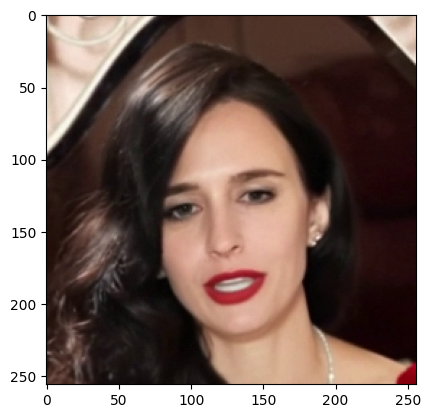

In [12]:
plt.imshow(cropped[51].permute(1, 2, 0).cpu().numpy()/255)

In [ ]:
print(centers[:8, :].cpu())
print(scales[:8].cpu())

tensor([[411.1799, 486.2936],
        [410.5586, 486.6238],
        [409.8705, 486.2303],
        [409.8454, 485.6248],
        [407.1741, 483.3664],
        [403.5238, 479.6957],
        [401.3889, 475.5485],
        [398.5702, 471.6290]])
tensor([2.1871, 2.1685, 2.1784, 2.1396, 2.1041, 2.1295, 2.1493, 2.1434])


In [ ]:
fa = FaceAlignment(device="cuda", face_detector="retina")
landmarks = fa.process()

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

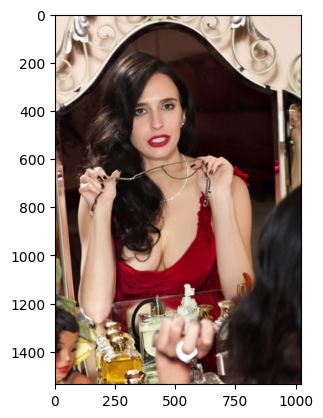

In [ ]:
display_id = 31
x1, y1, x2, y2 = bboxs[display_id]
h, w = y2 - y1, x2 - x1
fig, ax = plt.subplots()
ax.imshow(video[display_id])
rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='magenta', facecolor='none')
ax.add_patch(rect)

In [ ]:
src = torch.tensor([1, 1, 2, 2, 3, 4, 4, 4, 50, 60, 8])
unique, idx, counts = torch.unique_consecutive(src, return_inverse=True, return_counts=True, dim=0)


# _, ind_sorted = torch.sort(idx, stable=True)
# ind_sorted = torch.arange(len(idx), device=idx.device)
cum_sum = counts.cumsum(0)
cum_sum = torch.cat((torch.tensor([0]), cum_sum[:-1]))
# first_indicies = ind_sorted[cum_sum]
print(f"[DEBUG] first_indicies shape: {cum_sum.shape}, cumsum: {cum_sum.shape}", cum_sum)

[DEBUG] first_indicies shape: torch.Size([7]), cumsum: torch.Size([7]) tensor([ 0,  2,  4,  5,  8,  9, 10])
